# PreProcessing
* CIFAR-100 has 100 classes
* These 100 classes are Grouped to 20 Super Classes
* These 20 Super Classes are Grouped to 9 Groups
* MODEL SHOULD PREDICT THE CLASS, SUPERCLASS, GROUP

In [ ]:
!pip install scikit-learn

In [ ]:
!pip install matplotlib

  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 140.1 MB/s  0:00:00
Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.9 MB)
Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.6 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matpl

In [ ]:
!pip install seaborn

In [ ]:
import torch
from torch.utils.data import Dataset,DataLoader,random_split
from torchvision.datasets import CIFAR100
from torchvision import transforms,models
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

* THESE ARE 100 CLASSES OF CIFAR

In [ ]:
fine_classes = [
    'apple','aquarium_fish','baby','bear','beaver','bed','bee','beetle','bicycle','bottle',
    'bowl','boy','bridge','bus','butterfly','camel','can','castle','caterpillar','cattle',
    'chair','chimpanzee','clock','cloud','cockroach','couch','crab','crocodile','cup',
    'dinosaur','dolphin','elephant','flatfish','forest','fox','girl','hamster','house',
    'kangaroo','keyboard','lamp','lawn_mower','leopard','lion','lizard','lobster','man',
    'maple_tree','motorcycle','mountain','mouse','mushroom','oak_tree','orange','orchid',
    'otter','palm_tree','pear','pickup_truck','pine_tree','plain','plate','poppy',
    'porcupine','possum','rabbit','raccoon','ray','road','rocket','rose','sea','seal',
    'shark','shrew','skunk','skyscraper','snail','snake','spider','squirrel','streetcar',
    'sunflower','sweet_pepper','table','tank','telephone','television','tiger','tractor',
    'train','trout','tulip','turtle','wardrobe','whale','willow_tree','wolf','woman','worm'
]

* EACH SUPER CLASS HAS MULTIPLE CIFAR 100 CLASSES

In [ ]:
superclass_map = {
    'aquatic_mammals': ['beaver','dolphin','otter','seal','whale'],
    'fish': ['aquarium_fish','flatfish','ray','shark','trout'],
    'flowers': ['orchid','poppy','rose','sunflower','tulip'],
    'food_containers': ['bottle','bowl','can','cup','plate'],
    'fruit_and_vegetables': ['apple','mushroom','orange','pear','sweet_pepper'],
    'household_electrical_devices': ['clock','keyboard','lamp','telephone','television'],
    'household_furniture': ['bed','chair','couch','table','wardrobe'],
    'insects': ['bee','beetle','butterfly','caterpillar','cockroach'],
    'large_carnivores': ['bear','leopard','lion','tiger','wolf'],
    'large_manmade_outdoor_things': ['bridge','castle','house','road','skyscraper'],
    'large_natural_outdoor_scenes': ['cloud','forest','mountain','plain','sea'],
    'large_omnivores_and_herbivores': ['camel','cattle','chimpanzee','elephant','kangaroo'],
    'medium_mammals': ['fox','porcupine','possum','raccoon','skunk'],
    'non_insect_invertebrates': ['crab','lobster','snail','spider','worm'],
    'people': ['baby','boy','girl','man','woman'],
    'reptiles': ['crocodile','dinosaur','lizard','snake','turtle'],
    'small_mammals': ['hamster','mouse','rabbit','shrew','squirrel'],
    'trees': ['maple_tree','oak_tree','palm_tree','pine_tree','willow_tree'],
    'vehicles_1': ['bicycle','bus','motorcycle','pickup_truck','train'],
    'vehicles_2': ['lawn_mower','rocket','streetcar','tank','tractor']
}

* EACH GROUP HAS MULTIPLE SUPER CLASSES

In [ ]:
group_map = {
    'plants': ['flowers','trees','fruit_and_vegetables'],
    'vehicles': ['vehicles_1','vehicles_2'],
    'invertebrates': ['non_insect_invertebrates','insects'],
    'aquatic_animals': ['fish','aquatic_mammals'],
    'large_animals': ['large_carnivores','large_omnivores_and_herbivores'],
    'manmade_articles': ['food_containers','household_electrical_devices','household_furniture', 'large_manmade_outdoor_things'],
    'people': [ 'people'],
    'normal_terrestrial_animals': ['reptiles','medium_mammals','small_mammals'],
    'outdoor_scenes': [ 'large_natural_outdoor_scenes']
}

* FOR CIFAR 100 CREATING {CLASS_NAME:LABEL}
* FOR SUPERCLASS CREATING {SUPERCLASS_NAME:LABEL}
* FOR GROUP CREATING {GROUP_NAME:LABEL}

In [ ]:
fine_to_idx = {name:i for i,name in enumerate(fine_classes)}


super_names = list(superclass_map.keys())
super_to_idx = {name:i for i,name in enumerate(super_names)}

group_names = list(group_map.keys())
group_to_idx = {name:i for i,name in enumerate(group_names)}

* CREATING A DICTONARY { CIFAR_100_CLASSLABEL : SUPERCLASS_LABEL}
* CREATING A DICTONARY { SUPERCLASS_LABEL : GROUP_LABEL}

In [ ]:
fine_to_super = {}

for super_name, class_list in superclass_map.items():
    for cls in class_list:
        fine_id = fine_to_idx[cls]
        super_id = super_to_idx[super_name]
        fine_to_super[fine_id] = super_id


super_to_group = {}

for group_name, supers in group_map.items():
    group_id = group_to_idx[group_name]

    for s in supers:
        super_id = super_to_idx[s]
        super_to_group[super_id] = group_id

DATASET CLASS
* FOR EACH IMAGE GETTING THE CLASS LABEL
* USING THAT CLASS LABEL TO GET THE SUPER CLASS LABEL FROM fine_to_super dict
*  USING THAT SUPER CLASS LABEL GET THE GROUP LABEL FROM super_to_group dict

In [ ]:
class CIFAR100MultiTask(Dataset):
    def __init__(self, root='./data', train=True,download=True):
        self.transform = transforms.Compose([
                          transforms.ToTensor(),
                          transforms.Normalize(
                              mean=[0.5071, 0.4867, 0.4408],
                              std =[0.2675, 0.2565, 0.2761]
                          )
                      ])
        self.dataset = CIFAR100(
            root=root,
            train=train,
            download=download,
            transform=self.transform
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, image_label = self.dataset[idx]

        superclass_label = fine_to_super[image_label]
        group_label = super_to_group[superclass_label]

        return image, image_label, superclass_label, group_label

In [ ]:
class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv_1 = nn.Sequential(
            nn.Conv2d(in_channels,out_channels,kernel_size=3,stride=1,padding=1,bias=False), # maintain same shape
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )
        self.conv_2 = nn.Sequential(
            nn.Conv2d(out_channels,out_channels,kernel_size=3,stride=1,padding=1,bias=False), # maintain same shape
        )

        # residual path
        self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels,out_channels,kernel_size=1,stride=1,bias=False),
                nn.BatchNorm2d(out_channels)
            ) if in_channels != out_channels else nn.Identity()


    def forward(self, x):
        out = x
        out = self.conv_1(out)
        out = self.conv_2(out)
        res = self.shortcut(x)
        out = out + res
        return F.relu(out)

In [ ]:
class Residual_Down(nn.Module):
  def __init__(self, in_channel, out_channel, n_layers):
    super().__init__()
    self.n_layers = n_layers
    self.residual = nn.ModuleList([
        ResidualBlock(in_channel if i == 0 else out_channel, out_channel)
        for i in range(n_layers)
    ])

    self.downsample = nn.Conv2d(in_channels=out_channel, out_channels= out_channel,kernel_size=4,stride=2,padding=1)
  def forward(self, x):
    out = x
    for i in range(self.n_layers):
      out = self.residual[i](out)

    out = self.downsample(out)
    return out

In [ ]:
class CNNModel(nn.Module):
  def __init__(self,channels = [64,128,256,512], n_residuals_in_resBlock = 2):
    super().__init__()
    self.initial_conv = nn.Conv2d(in_channels = 3, out_channels=channels[0], kernel_size=3,padding=1,stride=1)

    self.blocks = nn.ModuleList([])
    for i in range(len(channels)-1):
      self.blocks.append(Residual_Down(in_channel=channels[i], out_channel=channels[i+1],n_layers=n_residuals_in_resBlock))

    self.pool = nn.AdaptiveAvgPool2d((1,1))
    self.dropout = nn.Dropout(0.3)
    self.image_label = nn.Linear(512, 100)
    self.image_super = nn.Linear(512, 20)
    self.image_group = nn.Linear(512, 9)

  def forward(self,x):
    x = self.initial_conv(x)
    for block in self.blocks:
      x = block(x)
    x = self.pool(x) #[B,512,1,1]
    x = x.flatten(1) #[B,512]
    x = self.dropout(x)
    image_label = self.image_label(x) #[B,100]
    image_super_label = self.image_super(x) #[B,20]
    image_group_label = self.image_group(x) # [B,9]
    return image_label,image_super_label,image_group_label

In [ ]:
@torch.no_grad()
def evaluate_model(model, loader, criterion, device):

    model.eval()
    total_loss = []

    true_class = []
    pred_class = []

    true_super = []
    pred_super = []

    true_group = []
    pred_group = []

    for images, image_labels, super_labels, group_labels in loader:

        images = images.to(device)
        image_labels = image_labels.to(device)
        super_labels = super_labels.to(device)
        group_labels = group_labels.to(device)

        x, y, z = model(images)

        loss1 = criterion(x, image_labels)
        loss2 = criterion(y, super_labels)
        loss3 = criterion(z, group_labels)

        loss = loss1 + loss2 + loss3
        total_loss.append(loss.item())

        p1 = torch.argmax(x, dim=1)
        p2 = torch.argmax(y, dim=1)
        p3 = torch.argmax(z, dim=1)

        true_class.extend(image_labels.cpu().numpy())
        pred_class.extend(p1.cpu().numpy())

        true_super.extend(super_labels.cpu().numpy())
        pred_super.extend(p2.cpu().numpy())

        true_group.extend(group_labels.cpu().numpy())
        pred_group.extend(p3.cpu().numpy())

    results = {
        "loss": np.mean(total_loss),

        "class_acc": accuracy_score(true_class, pred_class),
        "super_acc": accuracy_score(true_super, pred_super),
        "group_acc": accuracy_score(true_group, pred_group),

        "true_class": true_class,
        "pred_class": pred_class,

        "true_super": true_super,
        "pred_super": pred_super,

        "true_group": true_group,
        "pred_group": pred_group
    }

    return results

In [ ]:
def show_confusion_matrix(y_true, y_pred, title, figsize=(8,6)):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=figsize)
    sns.heatmap(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

In [ ]:
def plot_loss_curve(losses, split_name):

    plt.figure(figsize=(8,5))
    plt.plot(losses, marker='o')
    plt.title(f"{split_name} Training Loss vs Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

100%|██████████| 274/274 [01:10<00:00,  3.89it/s]


Epoch 1, loss: 9.8623


100%|██████████| 274/274 [01:10<00:00,  3.86it/s]


Epoch 2, loss: 9.7206


100%|██████████| 274/274 [01:13<00:00,  3.73it/s]


...

Epoch 98, loss: 0.1453


100%|██████████| 274/274 [01:12<00:00,  3.80it/s]


Epoch 99, loss: 0.7521


100%|██████████| 274/274 [01:12<00:00,  3.80it/s]


Epoch 100, loss: 0.4024

Final Test Results
Loss       : 10.409619096982277
image label Accuracy : 0.3592
Super label Accuracy  : 0.5236666666666666
Group label Accuracy  : 0.6297333333333334


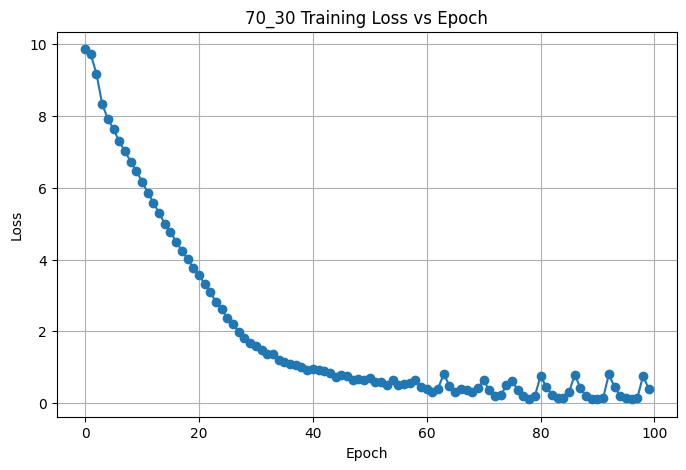

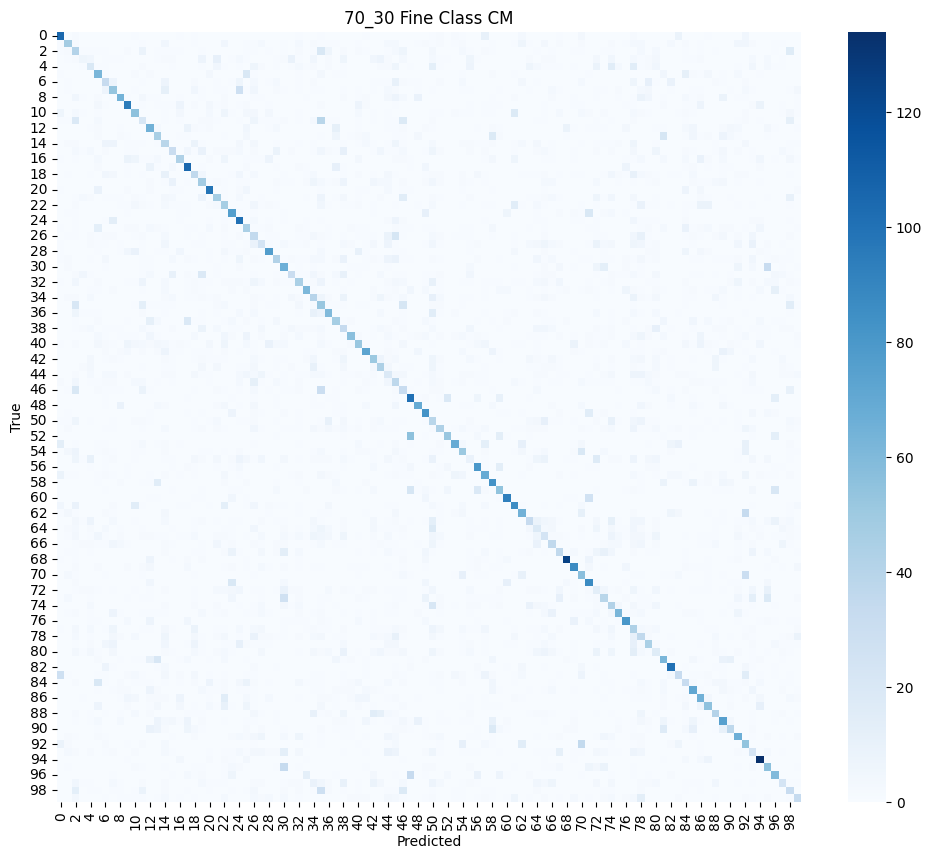

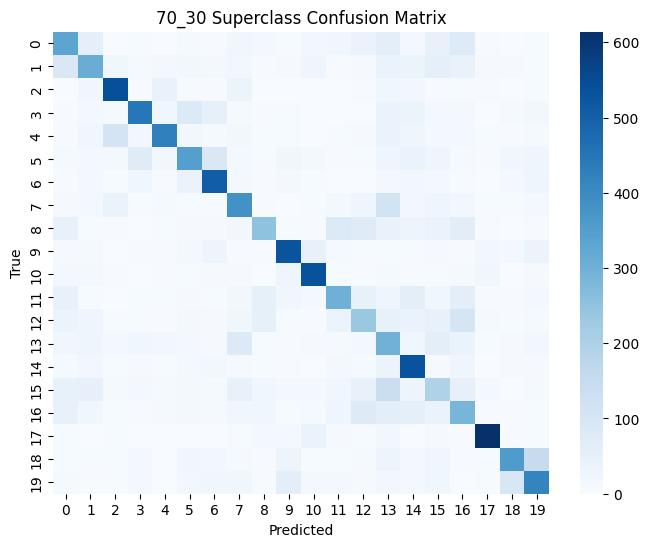

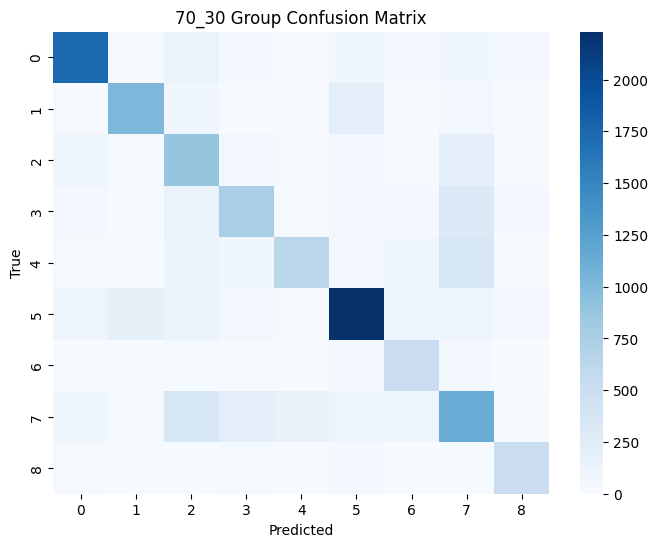

100%|██████████| 313/313 [01:24<00:00,  3.72it/s]


Epoch 1, loss: 9.2961


100%|██████████| 313/313 [01:24<00:00,  3.69it/s]


Epoch 2, loss: 8.3046


100%|██████████| 313/313 [01:24<00:00,  3.70it/s]


...

Epoch 98, loss: 0.2832


100%|██████████| 313/313 [01:23<00:00,  3.76it/s]


Epoch 99, loss: 0.2679


100%|██████████| 313/313 [01:23<00:00,  3.76it/s]


Epoch 100, loss: 0.4099

Final Test Results
Loss       : 9.231024446366709
image label Accuracy : 0.4067
Super label Accuracy  : 0.5731
Group label Accuracy  : 0.6803


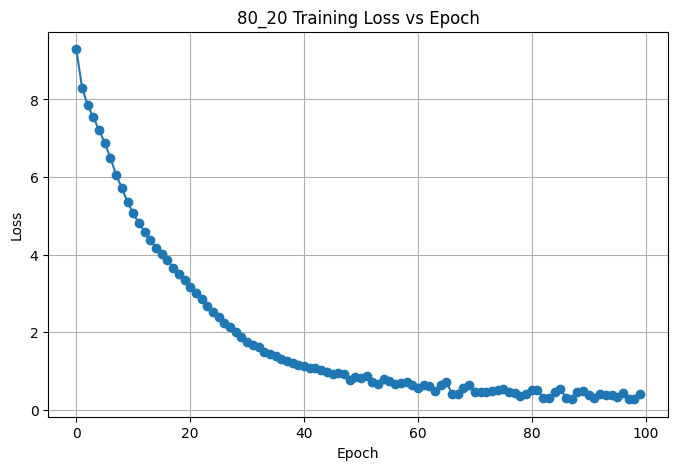

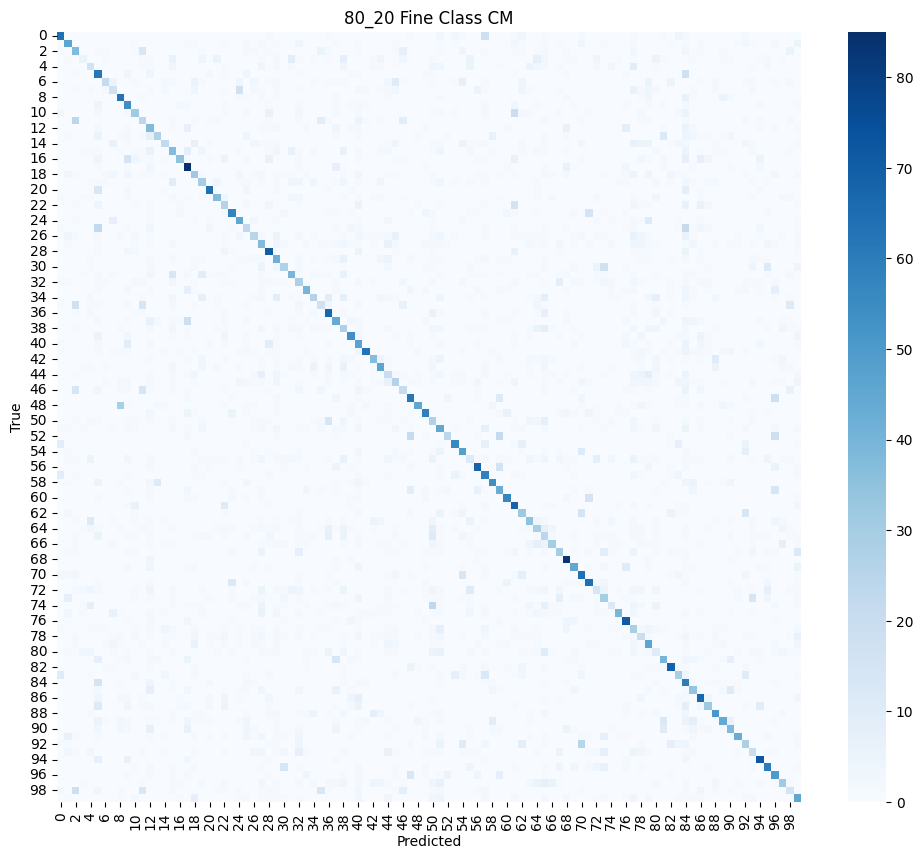

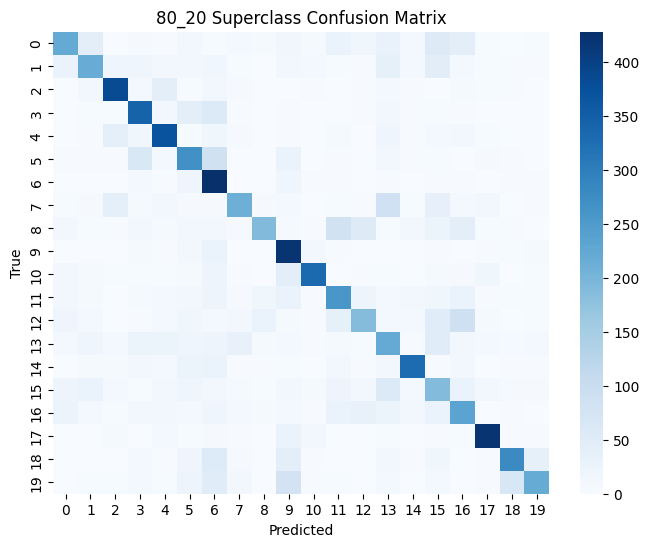

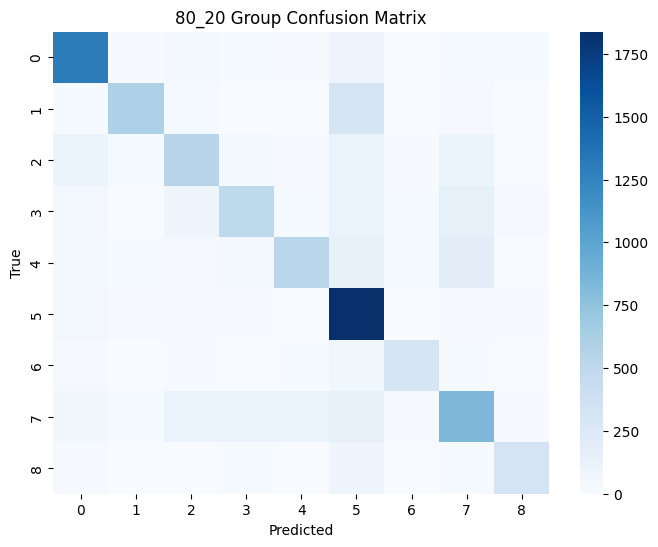

100%|██████████| 352/352 [01:35<00:00,  3.67it/s]


Epoch 1, loss: 9.1393


100%|██████████| 352/352 [01:36<00:00,  3.66it/s]


Epoch 2, loss: 8.1429


100%|██████████| 352/352 [01:36<00:00,  3.65it/s]


...

Epoch 98, loss: 0.3039


100%|██████████| 352/352 [01:33<00:00,  3.77it/s]


Epoch 99, loss: 0.2947


100%|██████████| 352/352 [01:33<00:00,  3.75it/s]


Epoch 100, loss: 0.2800

Final Test Results
Loss       : 7.997856569290161
image label Accuracy : 0.4402
Super label Accuracy  : 0.615
Group label Accuracy  : 0.7146


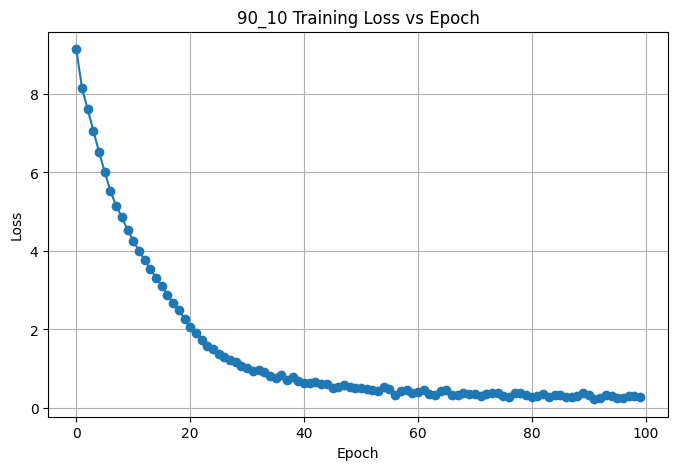

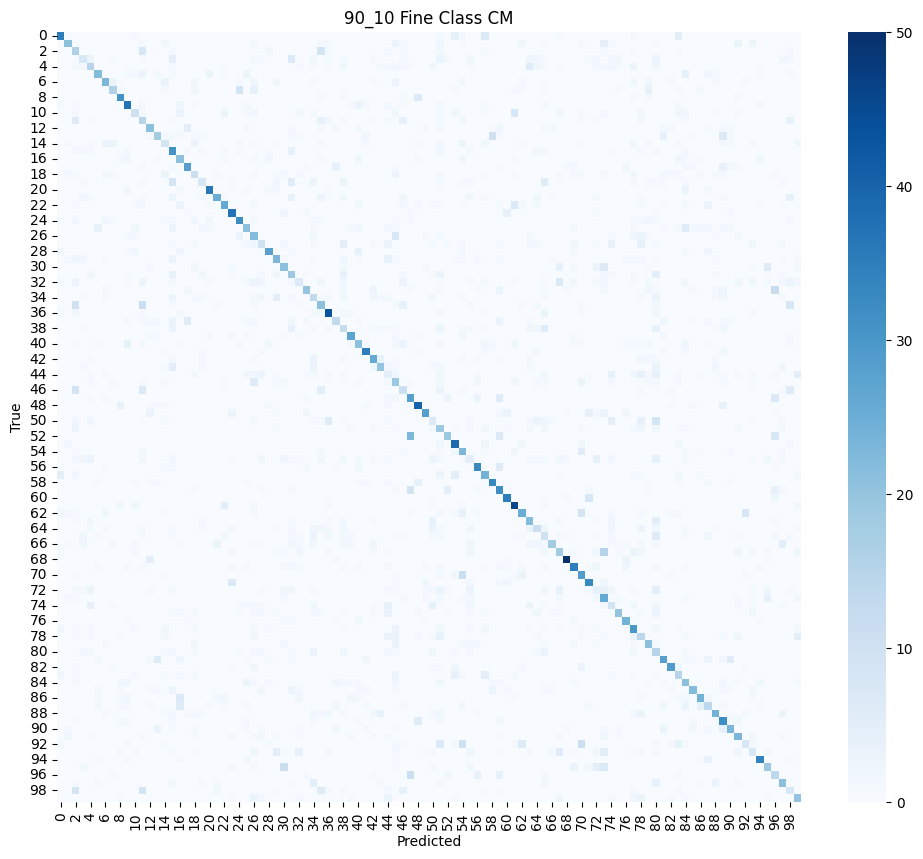

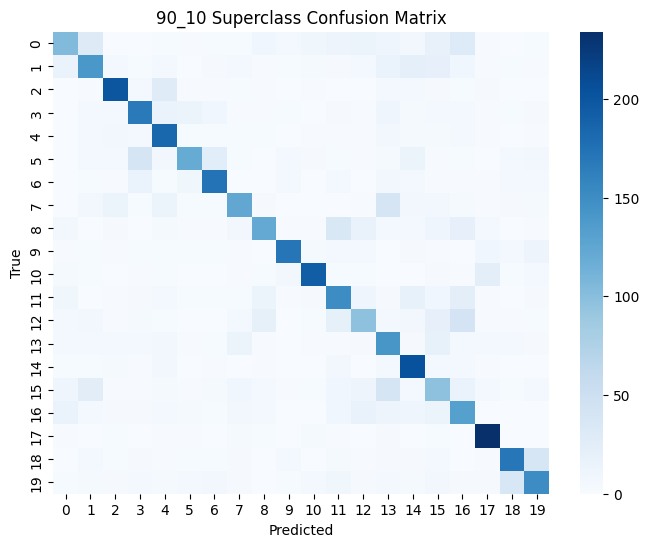

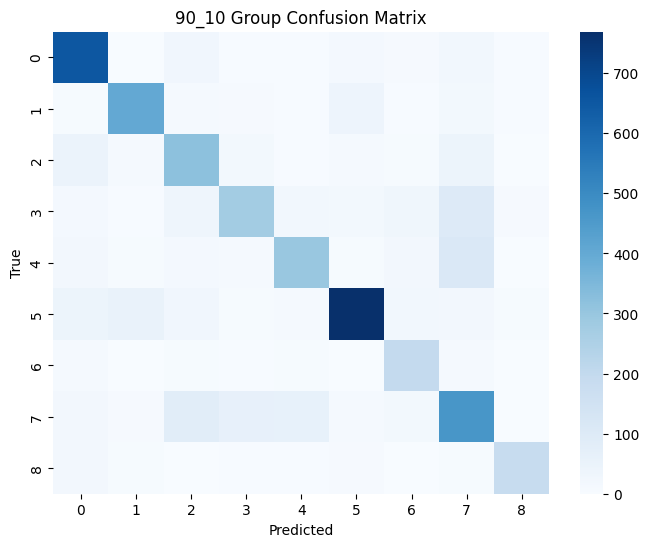

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size   = 128

epochs       = 100
learning_rate = 1e-3
weight_decay = 1e-4 # regularization

dataset = CIFAR100MultiTask()
split_configs = {
    "70_30": 0.70,
    "80_20": 0.80,
    "90_10": 0.90
}
criterion = nn.CrossEntropyLoss()

all_results = {}

for split_name, train_ratio in split_configs.items():

    train_size = int(len(dataset) * train_ratio)
    test_size  = len(dataset) - train_size
    train_ds, test_ds = random_split(dataset,[train_size, test_size])
    train_loader = DataLoader(train_ds,batch_size=batch_size,shuffle=True)
    test_loader = DataLoader(test_ds,batch_size=batch_size,shuffle=False)
    model = CNNModel().to(device)
    optimizer = optim.Adam( model.parameters(),lr=learning_rate,weight_decay=weight_decay)

    avg_loss_per_epoch = []
    for epoch in range(epochs):
      epoch_loss = []
      for images,image_labels,super_labels,group_labels in tqdm(train_loader):
        images = images.to(device)
        image_labels = image_labels.to(device)
        super_labels = super_labels.to(device)
        group_labels = group_labels.to(device)

        optimizer.zero_grad()
        x,y,z = model(images)
        loss1 = criterion(x, image_labels)
        loss2 = criterion(y, super_labels)
        loss3 = criterion(z, group_labels)
        total_loss = loss1+loss2+loss3

        total_loss.backward()
        optimizer.step()
        epoch_loss.append(total_loss.item())

      avg_epoch_loss = np.mean(epoch_loss)
      avg_loss_per_epoch.append(avg_epoch_loss)
      print(f'Epoch {epoch+1}, loss: {avg_epoch_loss:.4f}')


    metrics = evaluate_model(model, test_loader, criterion, device)

    print("\nFinal Test Results")
    print("Loss       :", metrics["loss"])
    print("image label Accuracy :", metrics["class_acc"])
    print("Super label Accuracy  :", metrics["super_acc"])
    print("Group label Accuracy  :", metrics["group_acc"])

    # Save results
    all_results[split_name] = metrics

    # ---------------- GRAPH ----------------
    plot_loss_curve(avg_loss_per_epoch, split_name)

    # ---------------- CONFUSION MATRICES ----------------
    show_confusion_matrix(
        metrics["true_class"],
        metrics["pred_class"],
        f"{split_name} Fine Class CM",
        figsize=(12,10)
    )

    show_confusion_matrix(
        metrics["true_super"],
        metrics["pred_super"],
        f"{split_name} Superclass Confusion Matrix"
    )

    show_confusion_matrix(
        metrics["true_group"],
        metrics["pred_group"],
        f"{split_name} Group Confusion Matrix"
    )

**VISION TRANSFOMER**

In [ ]:
num_image_labels = 100
num_super_labels = 20
num_group_labels = 9
patch_size = 8
attention_heads = 4
transformer_blocks = 4
mlp_hidden_nodes = 256
img_size = 32
img_channels = 3
num_patches = (img_size // patch_size)**2 #. 16 patches are formed here
embedding_dim = 64

In [ ]:
class PatchEmbedding(nn.Module):
  def __init__(self):
    super().__init__()
    # this become the [B, 64, 4, 4]
    self.patch_embed = nn.Conv2d(img_channels,embedding_dim,kernel_size = patch_size, stride=patch_size)
  def forward(self, x):
    # [B, 64, 4,4]
    x = self.patch_embed(x)
    #[B,64,16]
    x = x.flatten(2)
    #[B,16,64]
    x = x.transpose(1,2)
    # this form the each image made to 16 patches and each patch made to 64 dim
    return x

In [ ]:
class Transformer(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1 = nn.LayerNorm(embedding_dim)
    self.layer_norm2 = nn.LayerNorm(embedding_dim)
    self.mla = nn.MultiheadAttention(embedding_dim, attention_heads,batch_first=True)
    self.mlp = nn.Sequential(
        nn.Linear(embedding_dim, mlp_hidden_nodes),
        nn.GELU(), ## x * pi(x) where pi(x) is cummulative ,
        nn.Linear(mlp_hidden_nodes, embedding_dim)
    )
  def forward(self,x):
    out = x
    out = self.layer_norm1(out)
    # print(f'out of layer norm 1 {out.shape}') #[B,16,64]
    out = self.mla(out,out,out)[0]
    # print(f'out of mla {out.shape}') #[B,16,64]
    x = out + x
    out1 = x
    out1 = self.layer_norm2(out1)
    # print(f'out of layer norm 2 {out1.shape}') #[B,16,64]
    out1 = self.mlp(out1)
    # print(f'out of mlp {out1.shape}') #[B,16,64]
    x = out1 + x
    return x #[B,16,64]

In [ ]:
class FinalMlpHead(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.final_layer_norm = nn.LayerNorm(embedding_dim)
    self.mlp_head = nn.Linear(embedding_dim, num_classes)
  def forward(self,x):
    x = self.final_layer_norm(x)
    return self.mlp_head(x)

In [ ]:
class VisionTransformer(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embedding = PatchEmbedding()
    self.cls_token = nn.Parameter(torch.randn(1,1,64))
    self.position_embedding = nn.Parameter(torch.randn(1, 1+ num_patches, embedding_dim)) #[1,17,64]
    # this transformer is here no masked Multihead attention applied
    self.transformer_blocks = nn.Sequential(
        *[Transformer() for _ in range(transformer_blocks)]
    )
    self.final_linear_layer_imglabels = FinalMlpHead(num_image_labels)
    self.final_linear_layer_superlabels = FinalMlpHead(num_super_labels)
    self.final_linear_layyer_grplabels = FinalMlpHead(num_group_labels)

  def forward(self,x):
    x = self.patch_embedding(x)
    #[B, 16, 64]
    B = x.shape[0] # B
    cls_token = self.cls_token.expand(B,1,embedding_dim) #[1,1,64] to [B,1,64]
    x = torch.cat([cls_token,x], dim = 1) #[B,17,64]
    x = x + self.position_embedding #[B,17,64] + [1,17,64] --> Broadcasting applied here
    x = self.transformer_blocks(x)
    x = x[:,0,:] #[B,1,64]
    img_labels = self.final_linear_layer_imglabels(x) #[B,1,100]
    super_labels = self.final_linear_layer_superlabels(x) #[B,1,20]
    grp_labels = self.final_linear_layyer_grplabels(x) #[B,1,9]
    return img_labels,super_labels,grp_labels

100%|██████████| 547/547 [00:13<00:00, 40.97it/s]


Epoch 1, loss: 8.1889


100%|██████████| 547/547 [00:13<00:00, 41.37it/s]


Epoch 2, loss: 7.1301


100%|██████████| 547/547 [00:13<00:00, 41.48it/s]


...

Epoch 98, loss: 0.1258


100%|██████████| 547/547 [00:14<00:00, 38.95it/s]


Epoch 99, loss: 1.7237


100%|██████████| 547/547 [00:14<00:00, 38.66it/s]


Epoch 100, loss: 0.4626

Final Test Results
Loss       : 14.888433010020155
image label Accuracy : 0.2468
Super label Accuracy  : 0.39426666666666665
Group label Accuracy  : 0.507


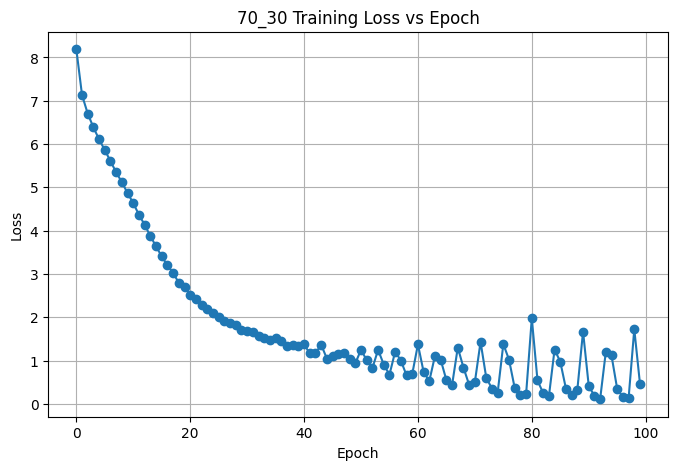

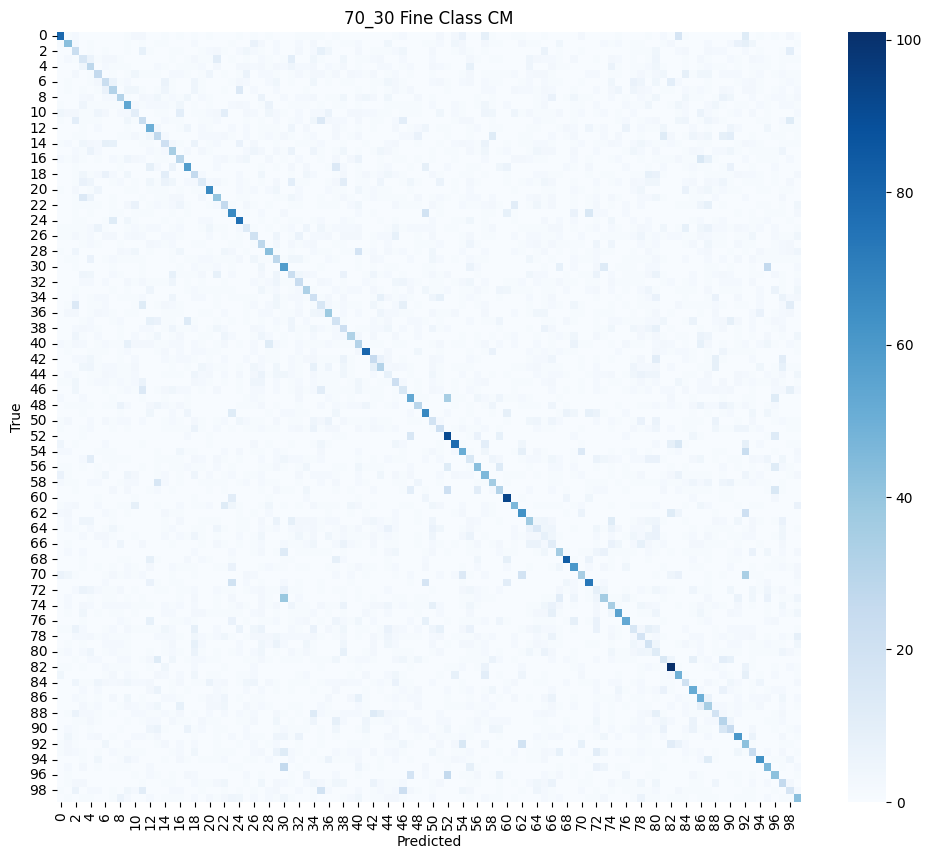

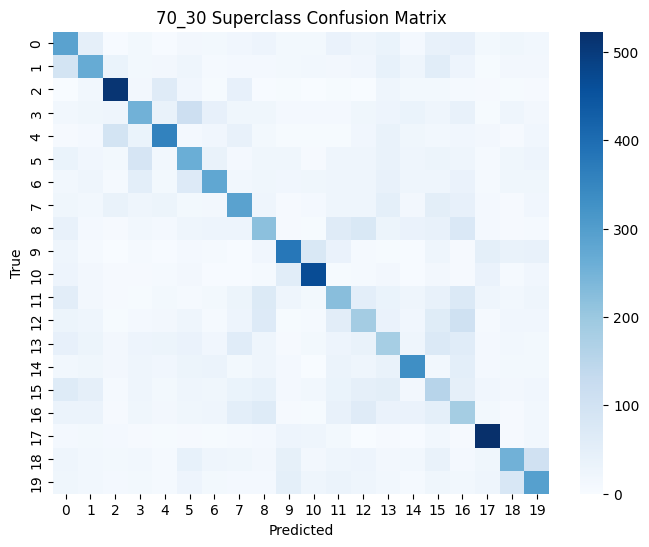

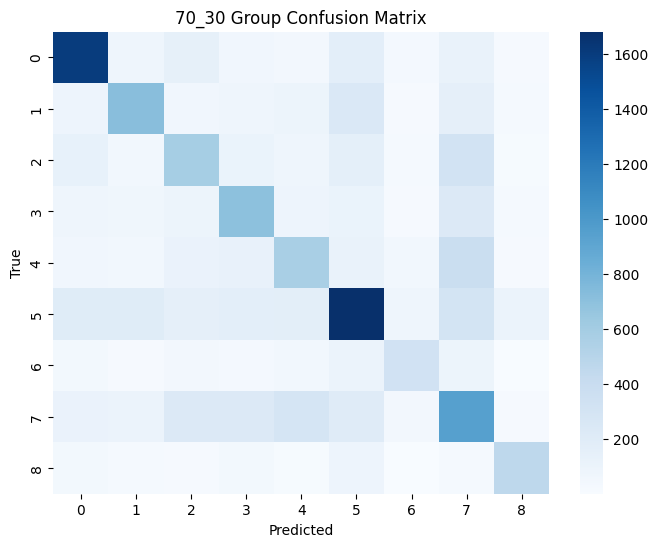

100%|██████████| 625/625 [00:16<00:00, 38.51it/s]


Epoch 1, loss: 8.0871


100%|██████████| 625/625 [00:16<00:00, 38.88it/s]


Epoch 2, loss: 7.0022


100%|██████████| 625/625 [00:15<00:00, 39.07it/s]


...

Epoch 98, loss: 1.7657


100%|██████████| 625/625 [00:15<00:00, 39.80it/s]


Epoch 99, loss: 0.4921


100%|██████████| 625/625 [00:15<00:00, 39.76it/s]


Epoch 100, loss: 0.2264

Final Test Results
Loss       : 15.568864968172305
image label Accuracy : 0.2542
Super label Accuracy  : 0.408
Group label Accuracy  : 0.519


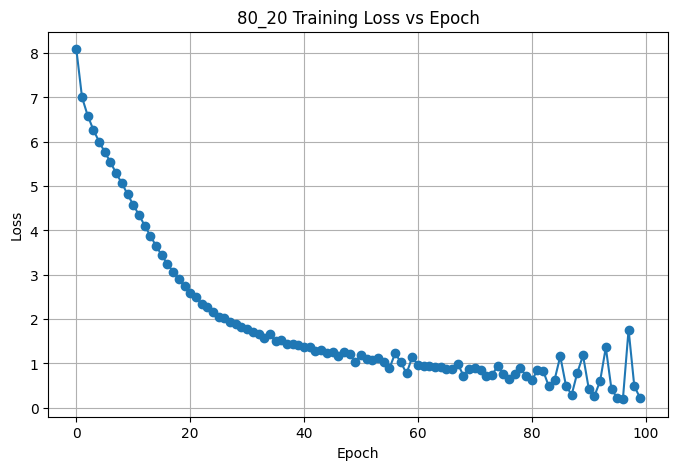

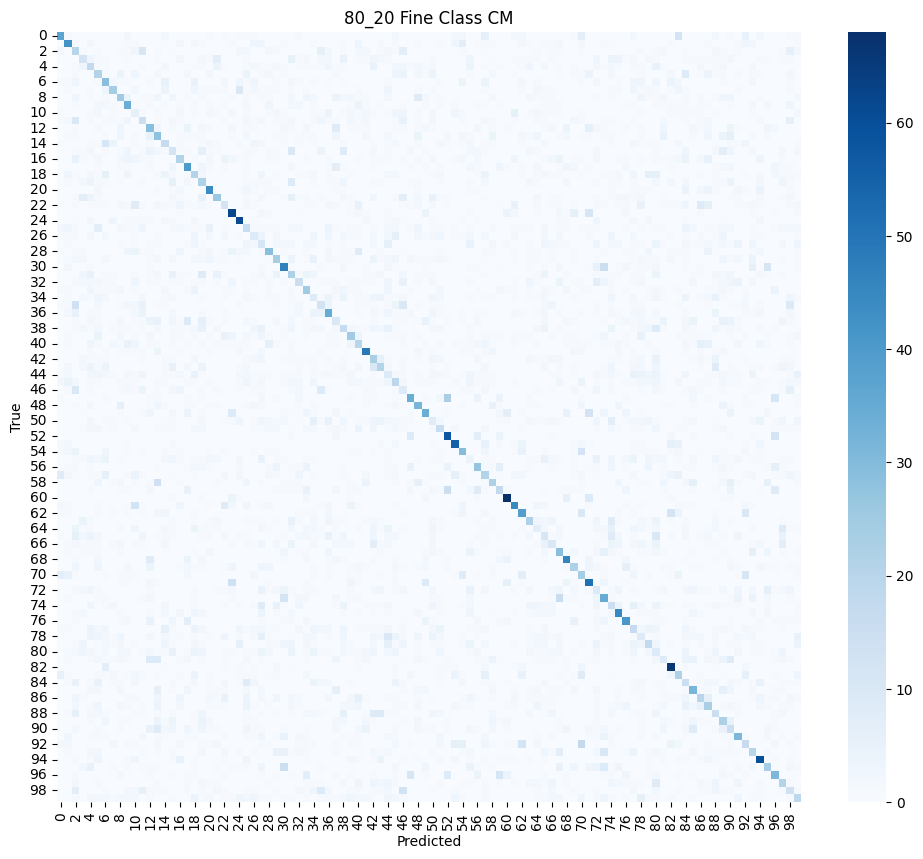

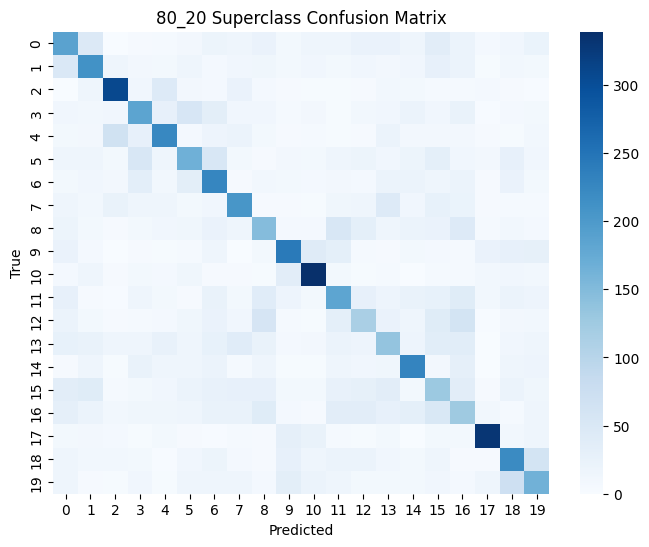

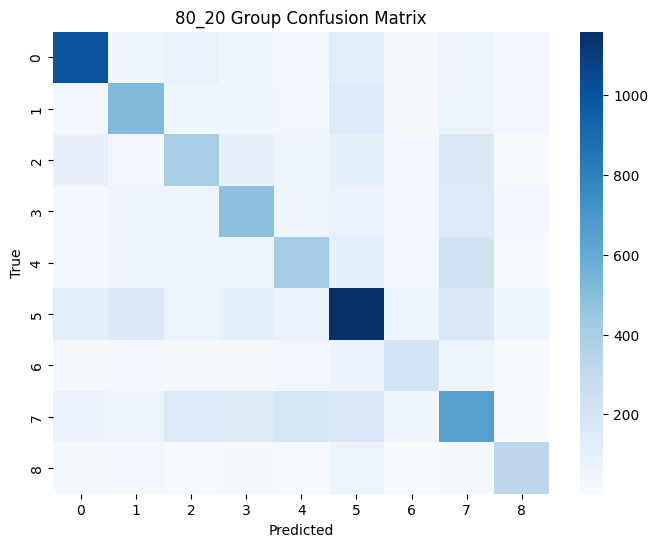

100%|██████████| 704/704 [00:17<00:00, 39.54it/s]


Epoch 1, loss: 8.0196


100%|██████████| 704/704 [00:17<00:00, 39.81it/s]


Epoch 2, loss: 6.9959


100%|██████████| 704/704 [00:17<00:00, 39.62it/s]


...

Epoch 98, loss: 0.6480


100%|██████████| 704/704 [00:18<00:00, 39.10it/s]


Epoch 99, loss: 0.8811


100%|██████████| 704/704 [00:17<00:00, 39.30it/s]


Epoch 100, loss: 0.6450

Final Test Results
Loss       : 15.946051452733293
image label Accuracy : 0.2458
Super label Accuracy  : 0.389
Group label Accuracy  : 0.5072


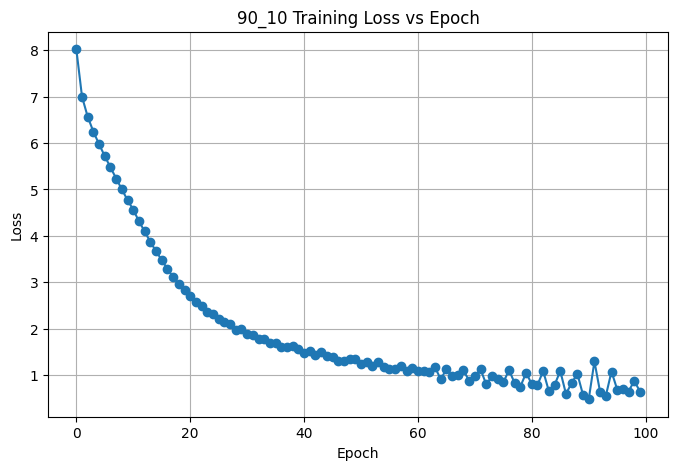

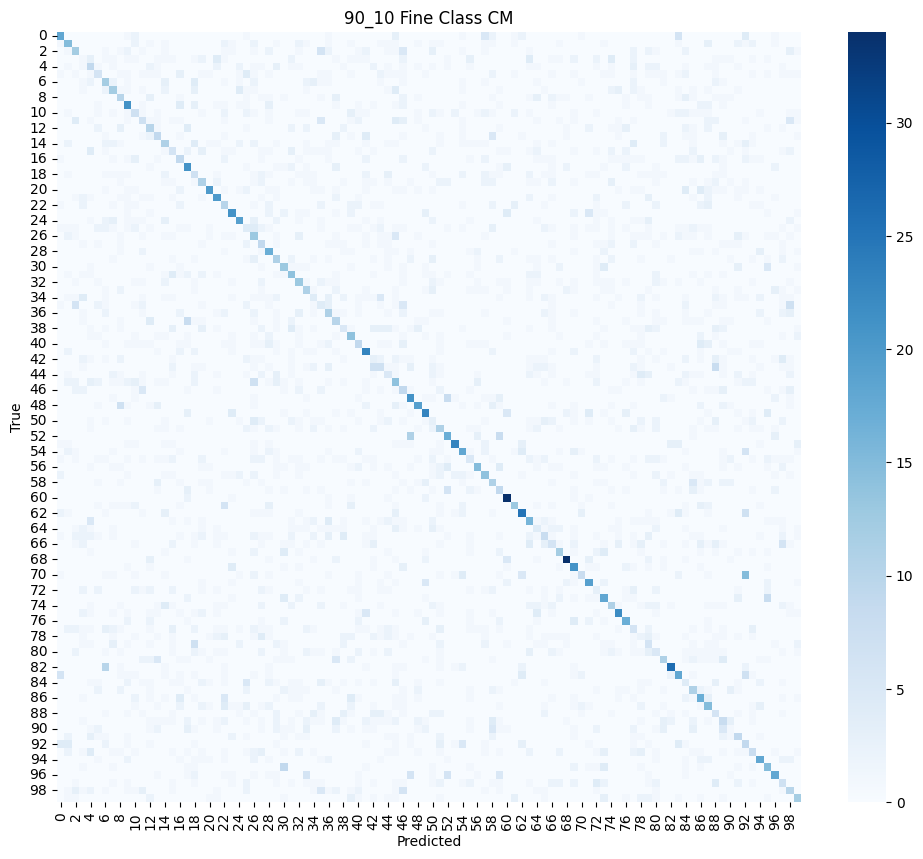

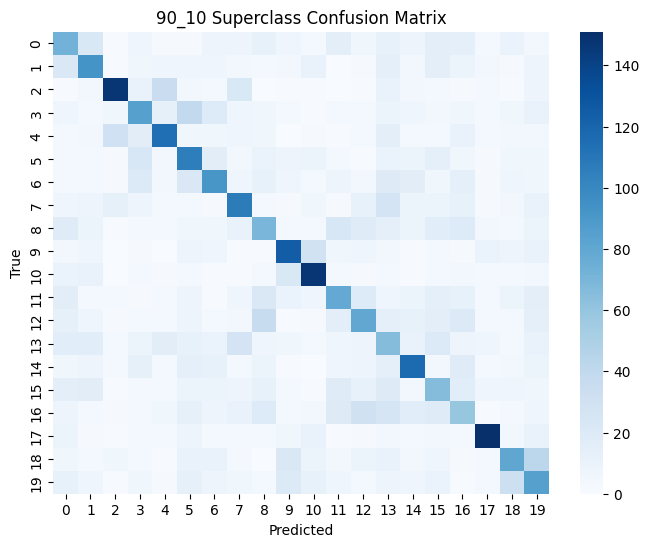

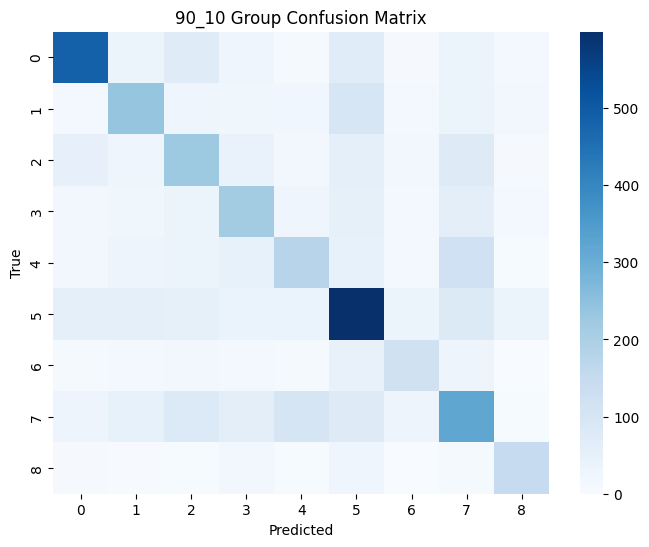

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
epochs       = 100
learning_rate = 1e-3
weight_decay = 1e-4 # regularization

dataset = CIFAR100MultiTask()
split_configs = {
    "70_30": 0.70,
    "80_20": 0.80,
    "90_10": 0.90
}
criterion = nn.CrossEntropyLoss()

all_results = {}

for split_name, train_ratio in split_configs.items():

    train_size = int(len(dataset) * train_ratio)
    test_size  = len(dataset) - train_size
    train_ds, test_ds = random_split(dataset,[train_size, test_size])
    train_loader = DataLoader(train_ds,batch_size=batch_size,shuffle=True)
    test_loader = DataLoader(test_ds,batch_size=batch_size,shuffle=False)
    model = VisionTransformer().to(device)
    optimizer = optim.Adam( model.parameters(),lr=learning_rate,weight_decay=weight_decay)

    avg_loss_per_epoch = []
    for epoch in range(epochs):
      epoch_loss = []
      for images,image_labels,super_labels,group_labels in tqdm(train_loader):
        images = images.to(device)
        image_labels = image_labels.to(device)
        super_labels = super_labels.to(device)
        group_labels = group_labels.to(device)

        optimizer.zero_grad()
        x,y,z = model(images)
        loss1 = criterion(x, image_labels)
        loss2 = criterion(y, super_labels)
        loss3 = criterion(z, group_labels)
        total_loss = loss1+loss2+loss3

        total_loss.backward()
        optimizer.step()
        epoch_loss.append(total_loss.item())

      avg_epoch_loss = np.mean(epoch_loss)
      avg_loss_per_epoch.append(avg_epoch_loss)
      print(f'Epoch {epoch+1}, loss: {avg_epoch_loss:.4f}')


    metrics = evaluate_model(model, test_loader, criterion, device)

    print("\nFinal Test Results")
    print("Loss       :", metrics["loss"])
    print("image label Accuracy :", metrics["class_acc"])
    print("Super label Accuracy  :", metrics["super_acc"])
    print("Group label Accuracy  :", metrics["group_acc"])

    # Save results
    all_results[split_name] = metrics

    # ---------------- GRAPH ----------------
    plot_loss_curve(avg_loss_per_epoch, split_name)

    # ---------------- CONFUSION MATRICES ----------------
    show_confusion_matrix(
        metrics["true_class"],
        metrics["pred_class"],
        f"{split_name} Fine Class CM",
        figsize=(12,10)
    )

    show_confusion_matrix(
        metrics["true_super"],
        metrics["pred_super"],
        f"{split_name} Superclass Confusion Matrix"
    )

    show_confusion_matrix(
        metrics["true_group"],
        metrics["pred_group"],
        f"{split_name} Group Confusion Matrix"
    )

**DEIT TransFormer**

**TEACHER MODEL RESNET50**

In [ ]:
num_image_labels = 100
num_super_labels = 20
num_grp_labels = 9

In [ ]:
teacher = models.resnet50(weights = models.ResNet50_Weights.IMAGENET1K_V2)
teacher.fc1 = nn.Linear(teacher.fc.in_features,num_image_labels)
teacher.fc2 = nn.Linear(teacher.fc.in_features,num_super_labels)
teacher.fc3 = nn.Linear(teacher.fc.in_features,num_grp_labels)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 322MB/s]


In [ ]:
class CIFAR100Teacher(Dataset):
    def __init__(self, root='./data', train=True,download=True):
        self.transform = transforms.Compose([
                              transforms.Resize((224,224)),
                              transforms.RandomHorizontalFlip(),
                              transforms.ToTensor(),
                              transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
                            ])
        self.dataset = CIFAR100(
            root=root,
            train=train,
            download=download,
            transform=self.transform
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, image_label = self.dataset[idx]

        superclass_label = fine_to_super[image_label]
        group_label = super_to_group[superclass_label]

        return image, image_label, superclass_label, group_label

In [ ]:
class MultiTaskRESNETTeacher(nn.Module):
    def __init__(self):
        super().__init__()

        # Load pretrained ResNet50
        self.backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V2
        )

        in_features = self.backbone.fc.in_features   # 2048

        # Remove last FC LAYER
        self.backbone.fc = nn.Identity()


        self.fc1 = nn.Linear(in_features, num_image_labels)
        self.fc2 = nn.Linear(in_features, num_super_labels)
        self.fc3 = nn.Linear(in_features, num_grp_labels)

    def forward(self, x):
        feat = self.backbone(x)     # [B,2048]

        out1 = self.fc1(feat)       #[B,100]
        out2 = self.fc2(feat)       # [B,20]
        out3 = self.fc3(feat)       # [B,9]

        return out1, out2, out3

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher = MultiTaskRESNETTeacher().to(device)

# freeze all the conv layers except the last classification
for param in teacher.backbone.parameters():
    param.requires_grad = False

for param in teacher.fc1.parameters():
    param.requires_grad = True

for param in teacher.fc2.parameters():
    param.requires_grad = True

for param in teacher.fc3.parameters():
    param.requires_grad = True
batch_size = 128
dataset = CIFAR100Teacher()
train_loader = DataLoader(dataset,batch_size=batch_size,shuffle=True)
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    list(teacher.fc1.parameters()) +
    list(teacher.fc2.parameters()) +
    list(teacher.fc3.parameters()),
    lr=1e-3
)

epochs = 30
avg_epoch_loss = []
for epoch in range(epochs):
    teacher.train()
    epoch_loss = []
    for images, y1, y2, y3 in tqdm(train_loader):
        images = images.to(device)
        y1 = y1.to(device)
        y2 = y2.to(device)
        y3 = y3.to(device)
        optimizer.zero_grad()
        logits1, logits2, logits3 = teacher(images)
        loss1 = criterion(logits1, y1)
        loss2 = criterion(logits2, y2)
        loss3 = criterion(logits3, y3)
        loss = loss1 + loss2 + loss3
        loss.backward()
        optimizer.step()
        epoch_loss.append(loss.item())
    avg_loss = np.mean(epoch_loss)
    avg_epoch_loss.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

100%|██████████| 169M/169M [00:16<00:00, 10.2MB/s] 
100%|██████████| 391/391 [01:55<00:00,  3.37it/s]


Epoch 1, Loss: 5.3712


100%|██████████| 391/391 [02:29<00:00,  2.62it/s]


Epoch 2, Loss: 3.7528


100%|██████████| 391/391 [01:48<00:00,  3.61it/s]


...

Epoch 28, Loss: 2.0375


100%|██████████| 391/391 [01:16<00:00,  5.08it/s]


Epoch 29, Loss: 2.0329


100%|██████████| 391/391 [01:32<00:00,  4.23it/s]

Epoch 30, Loss: 2.0012


In [ ]:
import os
import torch

os.makedirs('jl_fs/cnn_vit_deit', exist_ok=True)

path = 'jl_fs/cnn_vit_deit/teacher.pth'

torch.save({
    'model': teacher.state_dict(),
    'optimizer': optimizer.state_dict()
}, path)

print("Saved at:", path)
print("Exists:", os.path.exists(path))
print("Files:", os.listdir('jl_fs/cnn_vit_deit'))

Saved at: jl_fs/cnn_vit_deit/teacher.pth
Exists: True
Files: ['teacher.pth']


**ONCE THE TEACHER IS TRAINED**

**USING THE SAME**
* Patch Embedding CLASS
* Transformer Class
* FINALMLPHEAD Class
* IN VIT WE ADD THE DISTILL TOKEN AT THE END

In [ ]:
class CIFAR100MultiTaskDEIT(Dataset):
    def __init__(self, root='./data', train=True,download=True):
        self.transform_32 = transforms.Compose([
                          transforms.ToTensor(),
                          transforms.Normalize(
                              mean=[0.5071, 0.4867, 0.4408],
                              std =[0.2675, 0.2565, 0.2761]
                          )
                      ])
        self.transform_224 = transforms.Compose([
                              transforms.Resize((224,224)),
                              transforms.RandomHorizontalFlip(),
                              transforms.ToTensor(),
                              transforms.Normalize(mean=[0.485,0.456,0.406],
                                                   std=[0.229,0.224,0.225])
                            ])
        self.dataset = CIFAR100(
            root=root,
            train=train,
            download=download,
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, image_label = self.dataset[idx]
        img_32 = self.transform_32(image)
        img_224 = self.transform_224(image)

        superclass_label = fine_to_super[image_label]
        group_label = super_to_group[superclass_label]

        return img_32, img_224, image_label, superclass_label, group_label

In [ ]:
class DEITTransformer(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embedding = PatchEmbedding()
    self.cls_token = nn.Parameter(torch.zeros(1,1,embedding_dim))
    self.distill_token = nn.Parameter(torch.zeros(1,1,embedding_dim))

    self.position_embedding = nn.Parameter(torch.zeros(1, 2+ num_patches, embedding_dim)) #[1,18,64]
    # this transformer is here no masked Multihead attention applied
    self.transformer_blocks = nn.Sequential(
        *[Transformer() for _ in range(transformer_blocks)]
    )
    self.final_layernorm = nn.LayerNorm(embedding_dim)
    self.final_linear_layer_imglabels_cls = FinalMlpHead(num_image_labels)
    self.final_linear_layer_superlabels_cls = FinalMlpHead(num_super_labels)
    self.final_linear_layyer_grplabels_cls = FinalMlpHead(num_group_labels)

    self.final_linear_layer_imglabels_distil = FinalMlpHead(num_image_labels)
    self.final_linear_layer_superlabels_distil = FinalMlpHead(num_super_labels)
    self.final_linear_layyer_grplabels_distil = FinalMlpHead(num_group_labels)


  def forward(self,x):
    x = self.patch_embedding(x)
    #[B, 16, 64]
    B = x.shape[0] # B
    cls_token = self.cls_token.expand(B,1,embedding_dim) #[1,1,64] to [B,1,64]
    distil_token = self.distill_token.expand(B,1,embedding_dim) # [1,1,64] to [B,1,64]
    x = torch.cat([cls_token,x, distil_token], dim = 1) #[B,17,64]
    x = x + self.position_embedding #[B,18,64] + [1,18,64] --> Broadcasting applied here
    x = self.transformer_blocks(x)
    x1 = x[:,0,:] #[B,1,64]
    y1 =  x[:, -1, :]

    img_labels_cls = self.final_linear_layer_imglabels_cls(x1) #[B,1,100]
    super_labels_cls = self.final_linear_layer_superlabels_cls(x1) #[B,1,20]
    grp_labels_cls = self.final_linear_layyer_grplabels_cls(x1) #[B,1,9]

    image_labels_distil = self.final_linear_layer_imglabels_distil(y1)
    superlabels_distil = self.final_linear_layer_superlabels_distil(y1)
    grp_labels_distil = self.final_linear_layyer_grplabels_distil(y1)

    return img_labels_cls,super_labels_cls,grp_labels_cls, image_labels_distil,superlabels_distil, grp_labels_distil

In [ ]:
@torch.no_grad()
def evaluate_deit_model(model, loader,criterion,device):

    model.eval()

    total_loss = []
    true_class = []
    pred_class = []

    true_super = []
    pred_super = []

    true_group = []
    pred_group = []

    for img_32, img_224, image_labels, super_labels, group_labels in loader:


        img_32 = img_32.to(device)      # for DeiT student
        img_224 = img_224.to(device)    # unused here (teacher only if needed)

        image_labels = image_labels.to(device)
        super_labels = super_labels.to(device)
        group_labels = group_labels.to(device)

        # --------------------------------------------------
        # Forward Pass
        # Expected model output:
        # cls_fine, cls_super, cls_group,
        # dist_fine, dist_super, dist_group
        # --------------------------------------------------
        cls_x, cls_y, cls_z, dist_x, dist_y, dist_z = model(img_32)

        # --------------------------------------------------
        # Inference = Average CLS + DISTILL logits
        # --------------------------------------------------
        final_x = (cls_x + dist_x) / 2
        final_y = (cls_y + dist_y) / 2
        final_z = (cls_z + dist_z) / 2


        loss1 = criterion(final_x, image_labels)
        loss2 = criterion(final_y, super_labels)
        loss3 = criterion(final_z, group_labels)

        total_loss.append((loss1 + loss2 + loss3).item())

        # --------------------------------------------------
        # Predictions
        # --------------------------------------------------
        p1 = torch.argmax(final_x, dim=1)
        p2 = torch.argmax(final_y, dim=1)
        p3 = torch.argmax(final_z, dim=1)

        # --------------------------------------------------
        # Store labels
        # --------------------------------------------------
        true_class.extend(image_labels.cpu().numpy())
        pred_class.extend(p1.cpu().numpy())

        true_super.extend(super_labels.cpu().numpy())
        pred_super.extend(p2.cpu().numpy())

        true_group.extend(group_labels.cpu().numpy())
        pred_group.extend(p3.cpu().numpy())

    # ------------------------------------------------------
    # Metrics
    # ------------------------------------------------------
    results = {
        "loss": np.mean(total_loss),

        "class_acc": accuracy_score(true_class, pred_class),
        "super_acc": accuracy_score(true_super, pred_super),
        "group_acc": accuracy_score(true_group, pred_group),

        "true_class": true_class,
        "pred_class": pred_class,

        "true_super": true_super,
        "pred_super": pred_super,

        "true_group": true_group,
        "pred_group": pred_group
    }

    return results

100%|██████████| 352/352 [01:15<00:00,  4.67it/s]


Epoch 1, loss: 11.6855


100%|██████████| 352/352 [01:15<00:00,  4.69it/s]


Epoch 2, loss: 10.0212


100%|██████████| 352/352 [01:15<00:00,  4.67it/s]


...

Epoch 98, loss: 2.4699


100%|██████████| 352/352 [01:28<00:00,  3.98it/s]


Epoch 99, loss: 2.3990


100%|██████████| 352/352 [01:17<00:00,  4.53it/s]


Epoch 100, loss: 2.3777

Final Test Results
Loss       : 10.124086344242096
image label Accuracy : 0.2862
Super label Accuracy  : 0.423
Group label Accuracy  : 0.5402


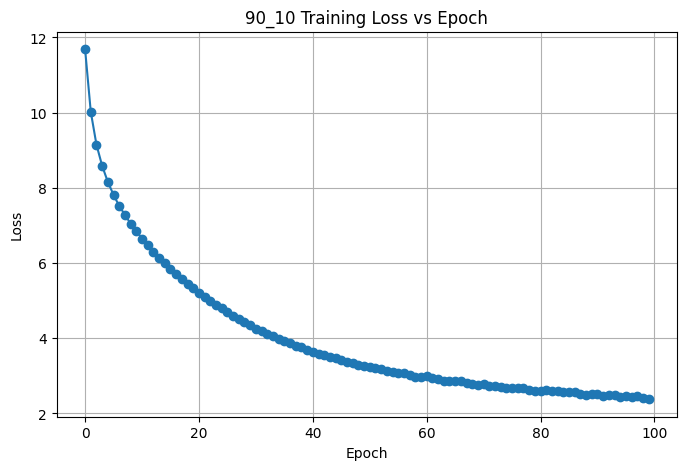

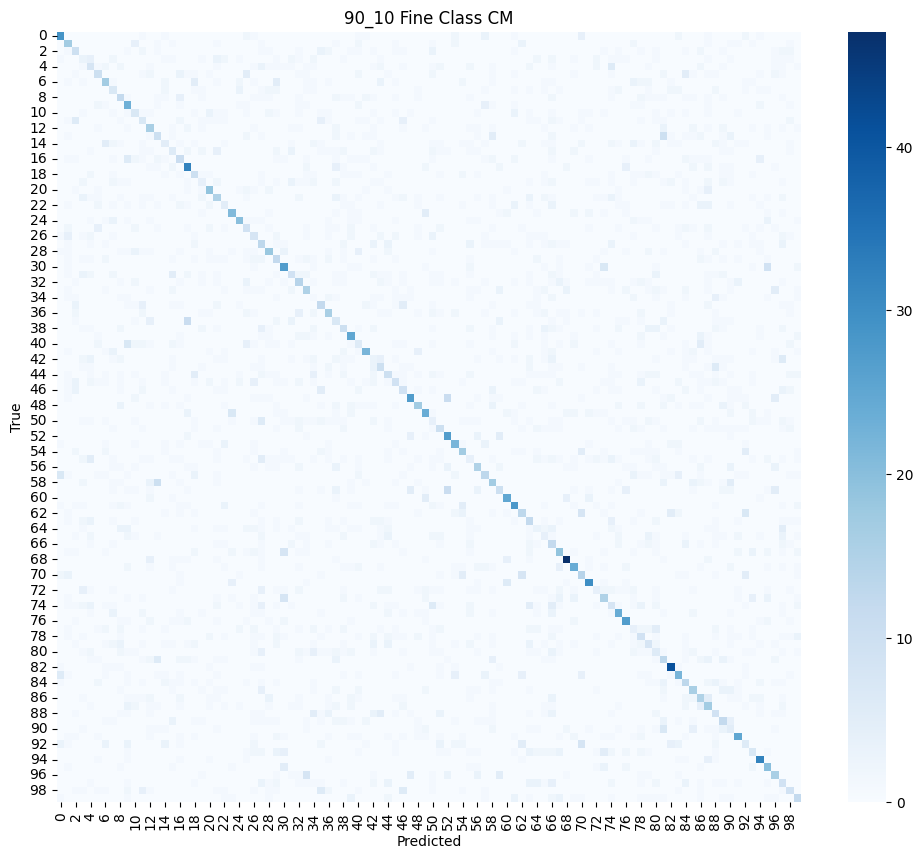

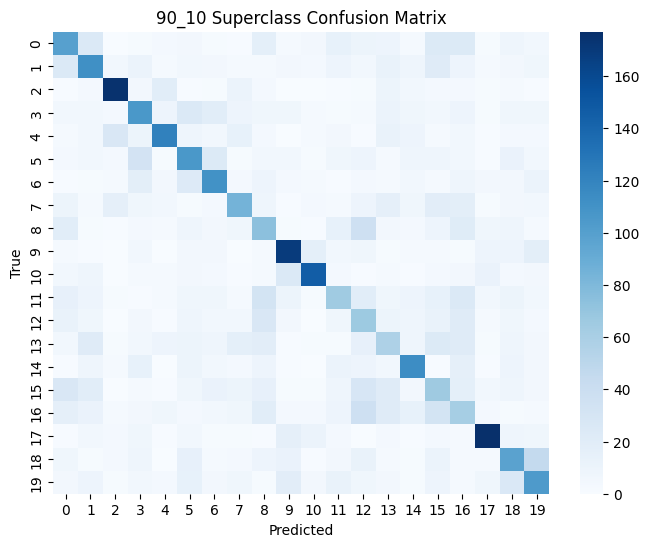

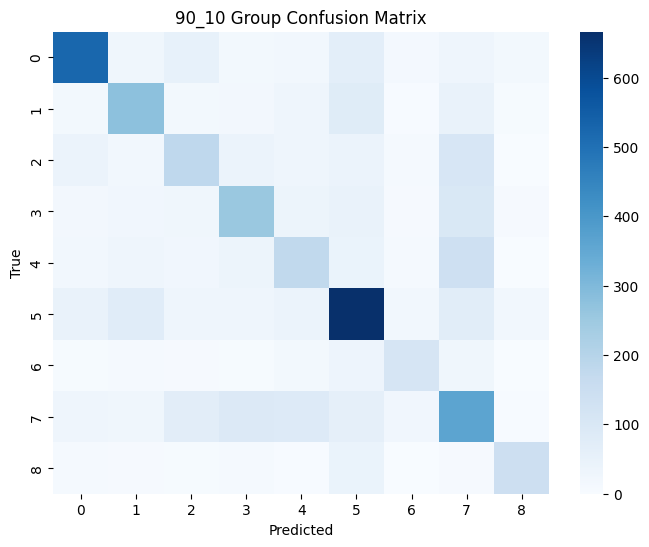

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 128
epochs       = 100
learning_rate = 3e-4
weight_decay = 1e-4 # regularization
T = 2
alpha = 0.5

dataset = CIFAR100MultiTaskDEIT()
split_configs = {
    "70_30": 0.70,
    "80_20": 0.80,
    "90_10": 0.90
}
criterion = nn.CrossEntropyLoss()
kl_loss = nn.KLDivLoss(reduction="batchmean")

all_results = {}
teacher = MultiTaskRESNETTeacher().to(device)
checkpoint_patch = 'jl_fs/cnn_vit_deit/teacher.pth'
ckpt = torch.load(checkpoint_patch, map_location=device)
teacher.load_state_dict(ckpt['model'])
teacher.eval()

for split_name, train_ratio in split_configs.items():

    train_size = int(len(dataset) * train_ratio)
    test_size  = len(dataset) - train_size
    train_ds, test_ds = random_split(dataset,[train_size, test_size])
    train_loader = DataLoader(train_ds,batch_size=batch_size,shuffle=True)
    test_loader = DataLoader(test_ds,batch_size=batch_size,shuffle=False)
    model = DEITTransformer().to(device)
    optimizer = optim.Adam( model.parameters(),lr=learning_rate,weight_decay=weight_decay)

    avg_loss_per_epoch = []
    for epoch in range(epochs):
      epoch_loss = []
      for img_32,img_224,image_labels,super_labels,group_labels in tqdm(train_loader):
        img_32 = img_32.to(device)
        img_224 = img_224.to(device)

        image_labels = image_labels.to(device)
        super_labels = super_labels.to(device)
        group_labels = group_labels.to(device)

        optimizer.zero_grad()
        x,y,z,a,b,c = model(img_32)

        with torch.no_grad():
            t1, t2, t3 = teacher(img_224)

        loss1 = criterion(x, image_labels)
        loss2 = criterion(y, super_labels)
        loss3 = criterion(z, group_labels)
        ce_total = loss1+loss2+loss3

        #KLDIVERGENCE BETWEEN t1,a and t2,b and t3,c
        kl1 = kl_loss(
            F.log_softmax(a / T, dim=1),
            F.softmax(t1 / T, dim=1)
        )

        kl2 = kl_loss(
            F.log_softmax(b / T, dim=1),
            F.softmax(t2 / T, dim=1)
        )

        kl3 = kl_loss(
            F.log_softmax(c / T, dim=1),
            F.softmax(t3 / T, dim=1)
        )

        kl_total = (kl1 + kl2 + kl3) * (T * T)

        total_loss = 0.5 * ce_total + 0.5*kl_total

        total_loss.backward()
        optimizer.step()
        epoch_loss.append(total_loss.item())

      avg_epoch_loss = np.mean(epoch_loss)
      avg_loss_per_epoch.append(avg_epoch_loss)
      print(f'Epoch {epoch+1}, loss: {avg_epoch_loss:.4f}')


    metrics = evaluate_deit_model(model, test_loader,criterion, device)

    print("\nFinal Test Results")
    print("Loss       :", metrics["loss"])
    print("image label Accuracy :", metrics["class_acc"])
    print("Super label Accuracy  :", metrics["super_acc"])
    print("Group label Accuracy  :", metrics["group_acc"])

    # Save results
    all_results[split_name] = metrics

    # ---------------- GRAPH ----------------
    plot_loss_curve(avg_loss_per_epoch, split_name)

    # ---------------- CONFUSION MATRICES ----------------
    show_confusion_matrix(
        metrics["true_class"],
        metrics["pred_class"],
        f"{split_name} Fine Class CM",
        figsize=(12,10)
    )

    show_confusion_matrix(
        metrics["true_super"],
        metrics["pred_super"],
        f"{split_name} Superclass Confusion Matrix"
    )

    show_confusion_matrix(
        metrics["true_group"],
        metrics["pred_group"],
        f"{split_name} Group Confusion Matrix"
    )

In [ ]:
torch.save({
    'model': teacher.state_dict(),
    'optimizer': optimizer.state_dict()
}, 'jl_fs/cnn_vit_deit/deit.pth')



Final Test Results
Loss       : 10.730151010771928
image label Accuracy : 0.2554666666666667
Super label Accuracy  : 0.39566666666666667
Group label Accuracy  : 0.5062


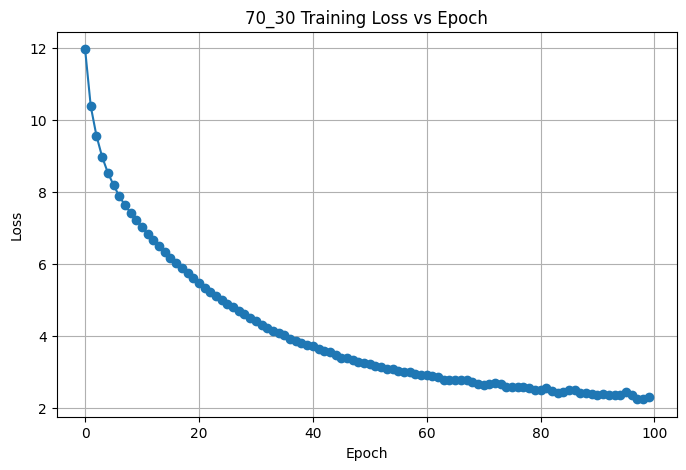

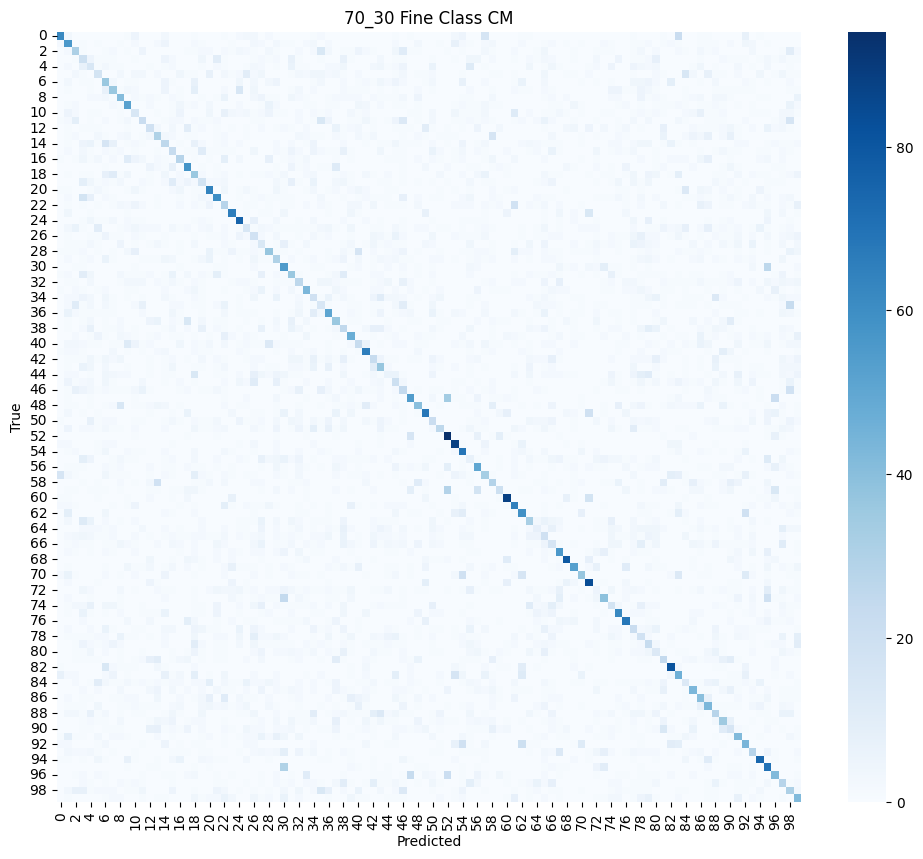

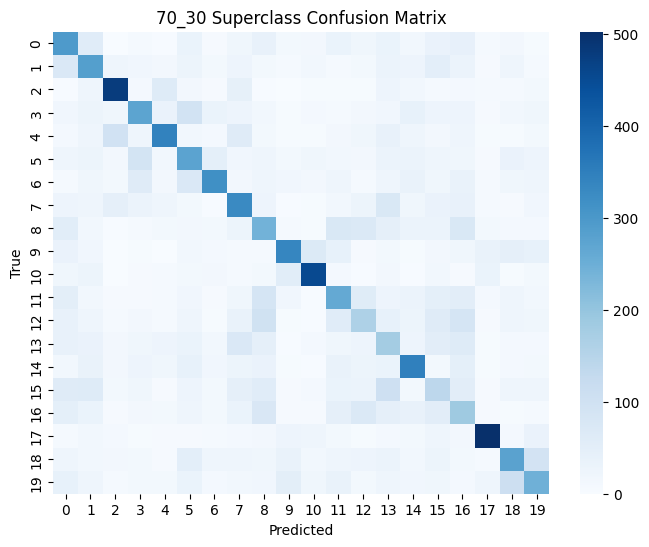

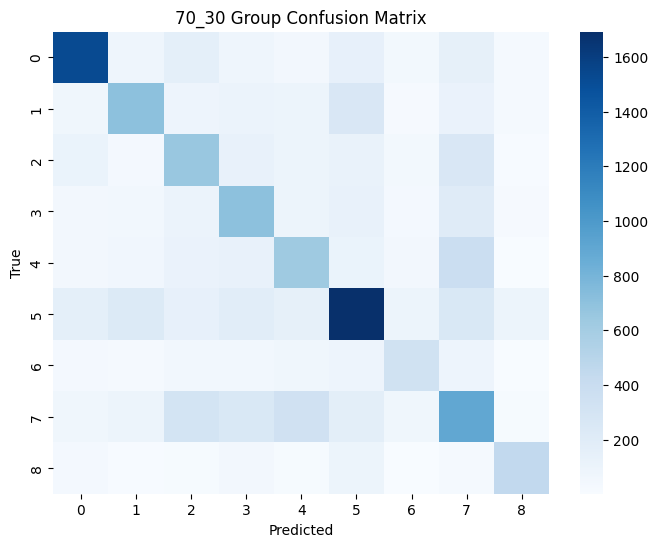

In [ ]:
    metrics = evaluate_deit_model(model, test_loader, criterion, device)

    print("\nFinal Test Results")
    print("Loss       :", metrics["loss"])
    print("image label Accuracy :", metrics["class_acc"])
    print("Super label Accuracy  :", metrics["super_acc"])
    print("Group label Accuracy  :", metrics["group_acc"])

    # Save results
    all_results[split_name] = metrics

    # ---------------- GRAPH ----------------
    plot_loss_curve(avg_loss_per_epoch, split_name)

    # ---------------- CONFUSION MATRICES ----------------
    show_confusion_matrix(
        metrics["true_class"],
        metrics["pred_class"],
        f"{split_name} Fine Class CM",
        figsize=(12,10)
    )

    show_confusion_matrix(
        metrics["true_super"],
        metrics["pred_super"],
        f"{split_name} Superclass Confusion Matrix"
    )

    show_confusion_matrix(
        metrics["true_group"],
        metrics["pred_group"],
        f"{split_name} Group Confusion Matrix"
    )


Final Test Results
Loss       : 10.092964582805392
image label Accuracy : 0.2715
Super label Accuracy  : 0.4173
Group label Accuracy  : 0.5376


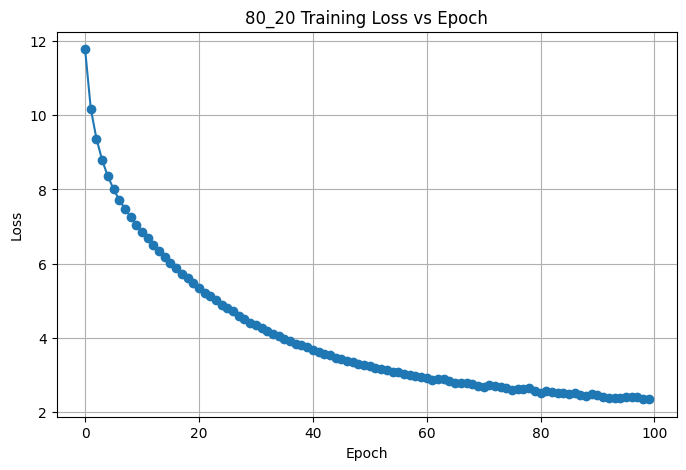

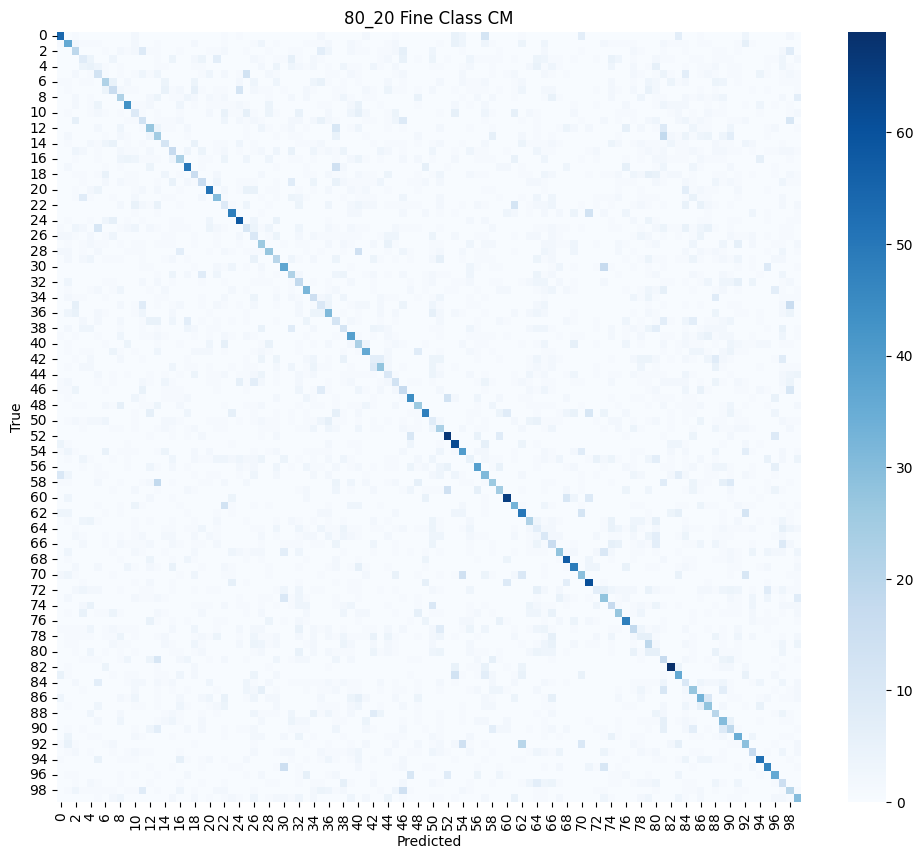

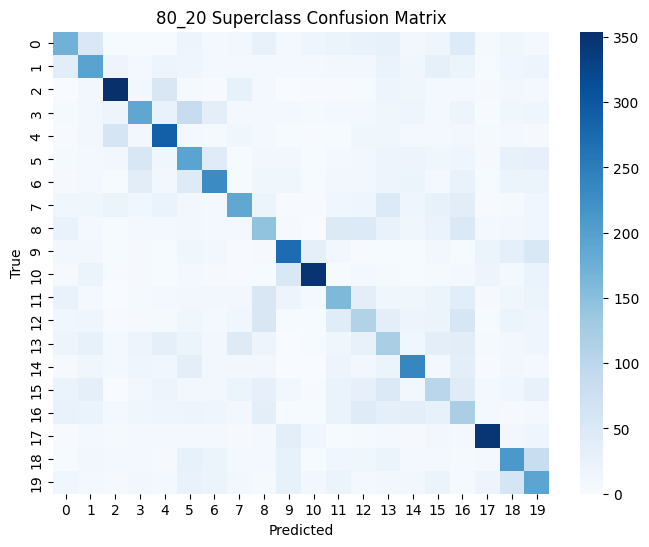

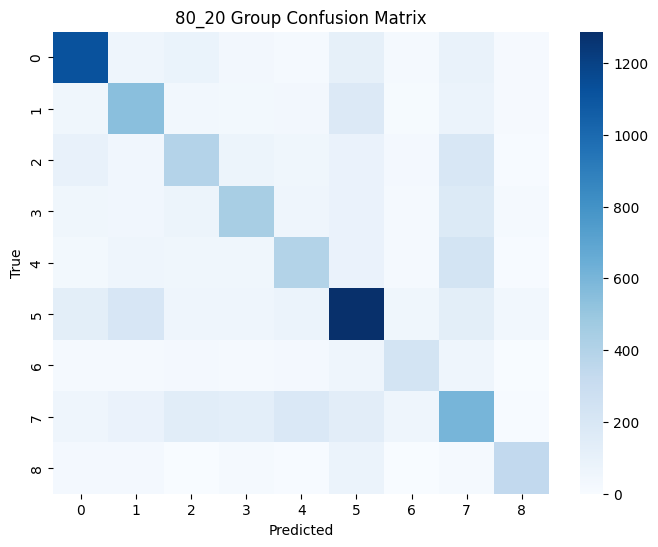

In [ ]:
    metrics = evaluate_deit_model(model, test_loader, criterion, device)

    print("\nFinal Test Results")
    print("Loss       :", metrics["loss"])
    print("image label Accuracy :", metrics["class_acc"])
    print("Super label Accuracy  :", metrics["super_acc"])
    print("Group label Accuracy  :", metrics["group_acc"])

    # Save results
    all_results[split_name] = metrics

    # ---------------- GRAPH ----------------
    plot_loss_curve(avg_loss_per_epoch, split_name)

    # ---------------- CONFUSION MATRICES ----------------
    show_confusion_matrix(
        metrics["true_class"],
        metrics["pred_class"],
        f"{split_name} Fine Class CM",
        figsize=(12,10)
    )

    show_confusion_matrix(
        metrics["true_super"],
        metrics["pred_super"],
        f"{split_name} Superclass Confusion Matrix"
    )

    show_confusion_matrix(
        metrics["true_group"],
        metrics["pred_group"],
        f"{split_name} Group Confusion Matrix"
    )